# LeetCode #261: Graph Valid Tree

https://leetcode.com/problems/graph-valid-tree/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| Union-Find ★ | O(n × α(n)) | O(n) |
| DFS / BFS | O(n) | O(n) |

## Understanding the Methods
### Union-Find (Optimal)
A valid tree has exactly n-1 edges and is connected. Use Union-Find: if adding an edge connects two nodes already in the same component, there is a cycle. After processing all edges, check that we have exactly n-1 edges (which ensures connectivity given no cycles).

### DFS / BFS
Build an adjacency list. Start DFS from node 0, tracking visited nodes. If we revisit a node (other than the parent), there is a cycle. After DFS, if all nodes are visited, the graph is connected. A valid tree requires both no cycle and full connectivity.

## Solutions

### C#

In [ ]:
public class Solution {
    private int[] parent, rank;

    public bool ValidTree(int n, int[][] edges) {
        if (edges.Length != n - 1) return false;
        parent = new int[n];
        rank = new int[n];
        for (int i = 0; i < n; i++) parent[i] = i;
        foreach (var e in edges) {
            if (!Union(e[0], e[1])) return false;
        }
        return true;
    }

    private int Find(int x) {
        if (parent[x] != x) parent[x] = Find(parent[x]);
        return parent[x];
    }

    private bool Union(int a, int b) {
        int ra = Find(a), rb = Find(b);
        if (ra == rb) return false;
        if (rank[ra] < rank[rb]) { int t = ra; ra = rb; rb = t; }
        parent[rb] = ra;
        if (rank[ra] == rank[rb]) rank[ra]++;
        return true;
    }
}

### Python

In [ ]:
class Solution:
    def validTree(self, n: int, edges: list[list[int]]) -> bool:
        if len(edges) != n - 1:
            return False
        parent = list(range(n))

        def find(x: int) -> int:
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x

        for a, b in edges:
            ra, rb = find(a), find(b)
            if ra == rb:
                return False
            parent[ra] = rb
        return True

### Go

In [ ]:
func validTree(n int, edges [][]int) bool {
    if len(edges) != n-1 {
        return false
    }
    parent := make([]int, n)
    for i := range parent {
        parent[i] = i
    }

    var find func(int) int
    find = func(x int) int {
        if parent[x] != x {
            parent[x] = find(parent[x])
        }
        return parent[x]
    }

    for _, e := range edges {
        ra, rb := find(e[0]), find(e[1])
        if ra == rb {
            return false
        }
        parent[ra] = rb
    }
    return true
}

### Rust

In [ ]:
impl Solution {
    pub fn valid_tree(n: i32, edges: Vec<Vec<i32>>) -> bool {
        let n = n as usize;
        if edges.len() != n - 1 {
            return false;
        }
        let mut parent: Vec<usize> = (0..n).collect();

        fn find(parent: &mut Vec<usize>, x: usize) -> usize {
            if parent[x] != x {
                parent[x] = find(parent, parent[x]);
            }
            parent[x]
        }

        for e in &edges {
            let (a, b) = (e[0] as usize, e[1] as usize);
            let (ra, rb) = (find(&mut parent, a), find(&mut parent, b));
            if ra == rb {
                return false;
            }
            parent[ra] = rb;
        }
        true
    }
}

## Example Scenarios

1. **Common Case** — `n = 5, edges = [[0,1],[0,2],[0,3],[1,4]]`
   **Input:** 5 nodes, 4 edges forming a star from node 0 plus one branch.
   Edge count = $n-1=4$ (necessary condition met). Union-Find merges all nodes into one component with no cycle detected. Valid tree.

2. **Slightly Complex** — `n = 5, edges = [[0,1],[1,2],[2,3],[1,3]]`
   **Input:** 5 nodes but 4 edges where nodes 1-2-3 form a cycle.
   Edge count = $4 = n-1$, but union of $(1,3)$ finds both already in the same set — cycle detected. Not a valid tree.

3. **Edge Case: Time Factor** — `n = 100000, edges` form a single chain $0-1-2-\cdots-99999$
   **Input:** $10^5$ nodes in a long chain ($99{,}999$ edges).
   Union-Find with path compression and union by rank runs in $O(n \cdot \alpha(n)) \approx O(n)$ — nearly linear even for the largest input.

4. **Edge Case: Space Factor** — `n = 1, edges = []`
   **Input:** A single node with no edges (minimum valid input).
   $0$ edges $= n-1 = 0$. One node alone is trivially a valid tree. The parent array has size 1.

5. **Almost-Impossible but Plausible** — `n = 5, edges = [[0,1],[2,3]]`
   **Input:** 5 nodes but only 2 edges — a disconnected forest.
   Edge count $= 2 \neq n-1 = 4$, so the early check immediately returns false. Three separate components (node 4 is isolated). Not a tree.

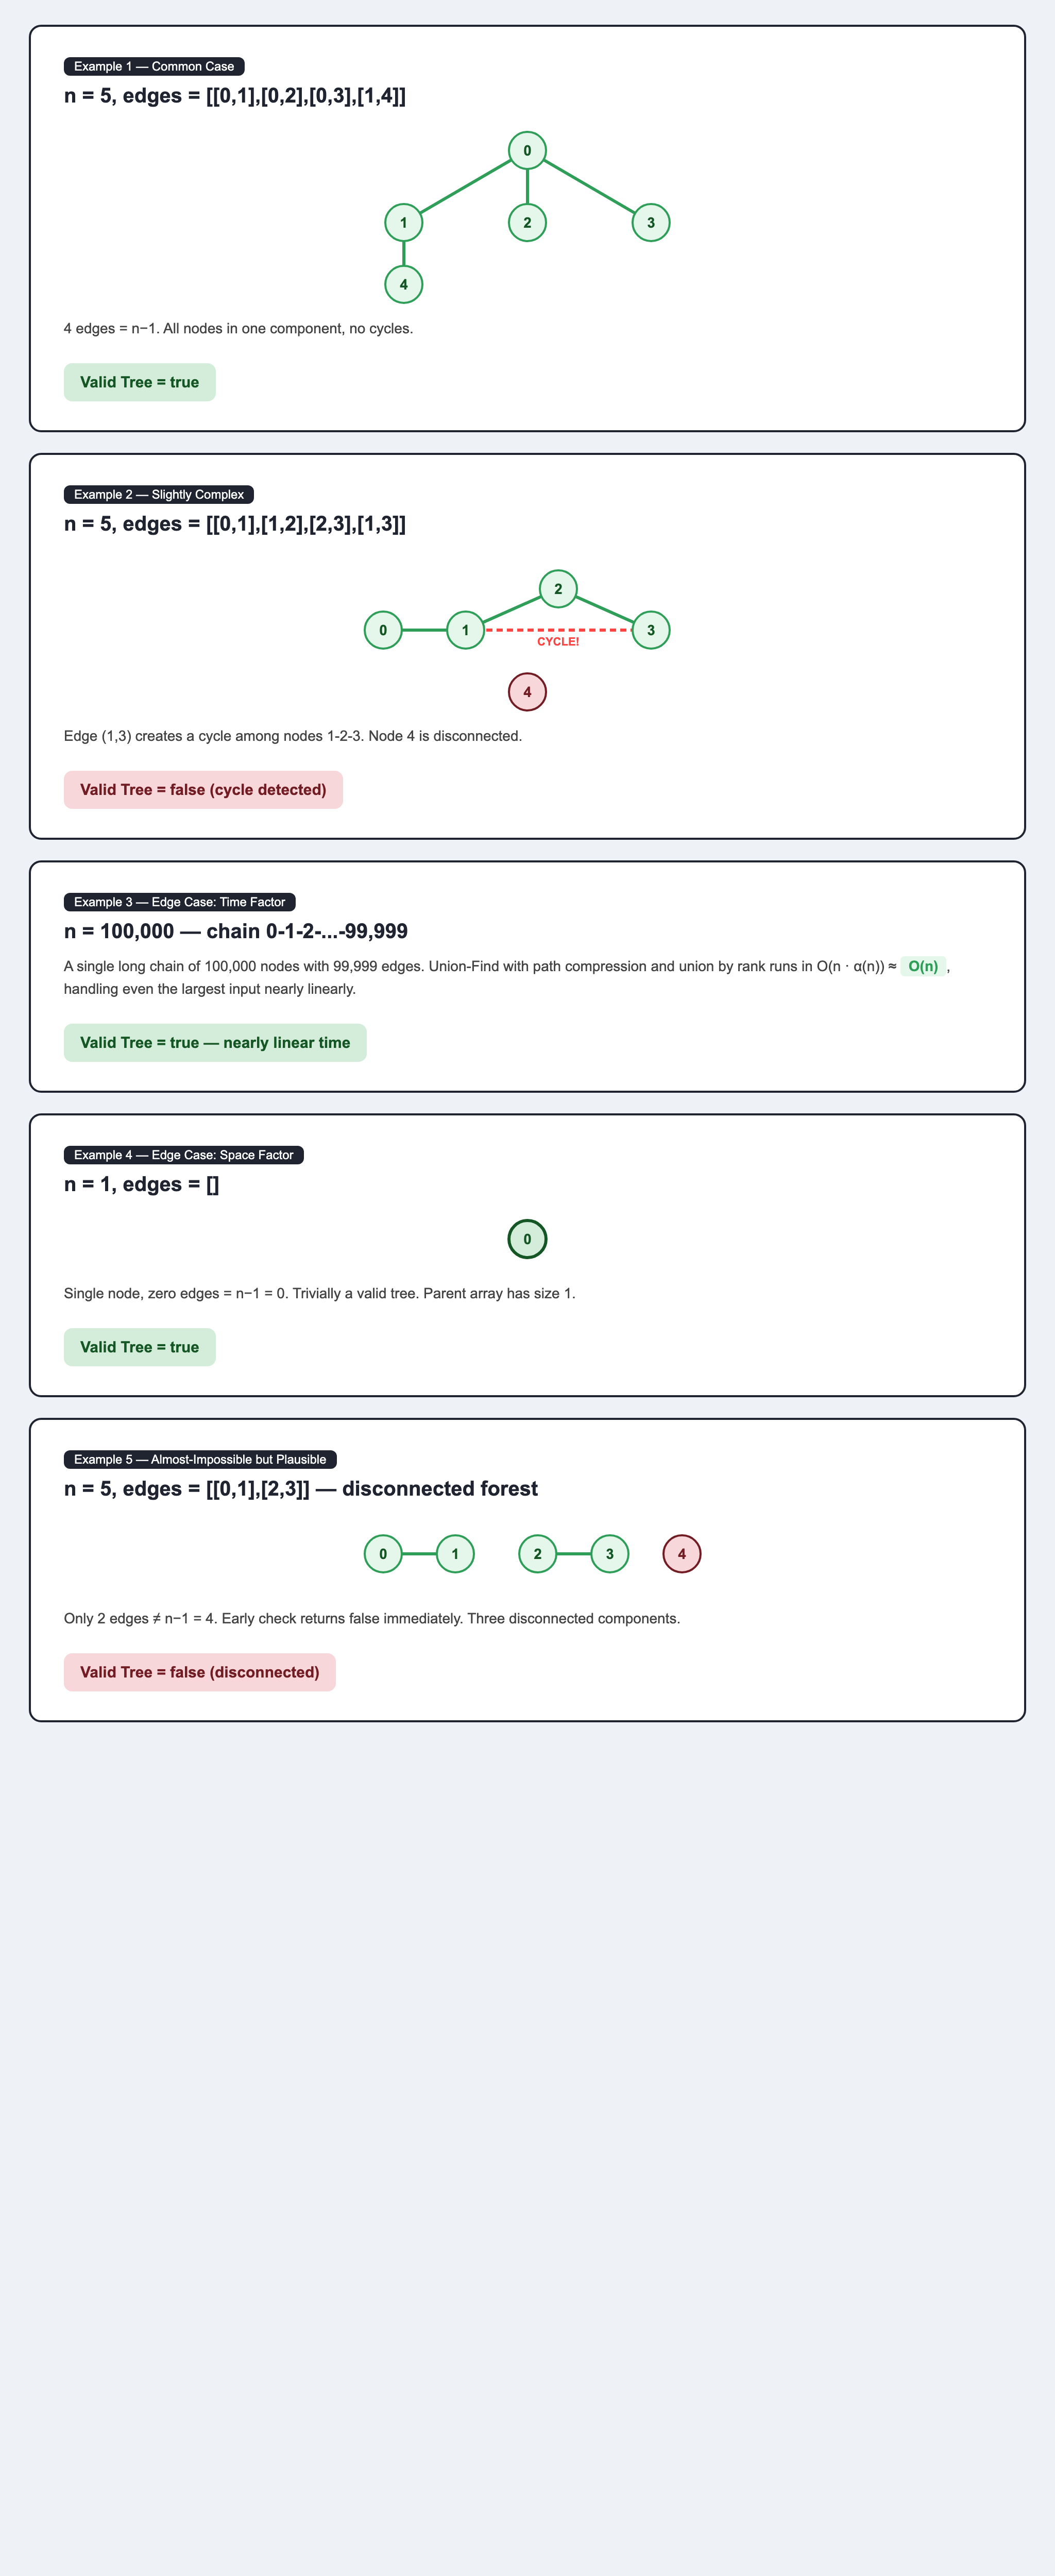